# v2 Generic Framework: Training Demo

Demonstrates the **v2 generic MDP framework** on the basic investment model.

| Feature | v1 | v2 (this notebook) |
|---------|----|---------|
| Data pipeline | Pre-generated offline dataset | Pre-generated offline dataset (`DataGenerator`) |
| Data / training | Coupled (trainers own RNG) | **Separated** (trainers receive dict, no RNG) |
| State decomposition | Monolithic `s` | `s = [s_endo | s_exo]` (exo pre-computable) |
| Normalization | Per-variable (log-zscore, zscore) | Running z-score (EMA, warm-up then frozen) |
| Output head | Domain-specific | Affine-rescaled: `center + sqrt(half_range) * raw`, then clip |
| Architecture | Dense + ReLU/Swish | Dense (bias) + SiLU |
| Environment | Hard-coded in trainer | `MDPEnvironment` abstraction |
| Methods | LR, ER, BR | LR, ER, BRM |

## Workflow
1. **Environment** — wrap model logic in `MDPEnvironment`
2. **Data** — `DataGenerator` pre-computes exo trajectories and flattened transitions
3. **Networks** — generic policy + value networks
4. **Train** — `train_lr` / `train_er` / `train_brm` receive dataset dicts, no RNG
5. **Validate** — compare to frictionless analytical solution
6. **Checkpoint** — save under `results/v2-{timestamp}/`

---
# Section 0: Setup

In [1]:
import sys, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

# v2 modules
from src.v2.environments.basic_investment import BasicInvestmentEnv
from src.v2.data.generator import DataGenerator, DataGeneratorConfig
from src.v2.networks.policy import PolicyNetwork
from src.v2.networks.state_value import StateValueNetwork
from src.v2.trainers.config import LRConfig, ERConfig, BRMConfig, OptimizerConfig
from src.v2.trainers.lr import train_lr
from src.v2.trainers.er import train_er
from src.v2.trainers.brm import train_brm

# Shared economy modules
from src.economy.parameters import EconomicParams, ShockParams
from src.utils.analysis import compute_frictionless_policy

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.16.2
GPU available: True


/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
TRAINING_PROFILE = "BALANCED"  # "FAST_DEBUG" | "BALANCED" | "PRODUCTION"

if TRAINING_PROFILE == "FAST_DEBUG":
    N_PATHS       = 1000
    HORIZON       = 32
    LR_STEPS      = 300
    ER_STEPS      = 500
    BRM_STEPS     = 500
    BATCH_SIZE    = 128
    N_NEURONS     = 32
    EVAL_INTERVAL = 50

elif TRAINING_PROFILE == "BALANCED":
    N_PATHS       = 5000
    HORIZON       = 64
    LR_STEPS      = 1000
    ER_STEPS      = 2000
    BRM_STEPS     = 2000
    BATCH_SIZE    = 256
    N_NEURONS     = 128
    EVAL_INTERVAL = 100

else:  # PRODUCTION
    N_PATHS       = 10000
    HORIZON       = 64
    LR_STEPS      = 5000
    ER_STEPS      = 10000
    BRM_STEPS     = 10000
    BATCH_SIZE    = 256
    N_NEURONS     = 256
    EVAL_INTERVAL = 500

MASTER_SEED = (20, 26)

print(f"Profile: {TRAINING_PROFILE}")
print(f"  Paths={N_PATHS}, horizon={HORIZON}")
print(f"  LR={LR_STEPS}, ER={ER_STEPS}, BRM={BRM_STEPS} steps")
print(f"  Batch={BATCH_SIZE}, neurons={N_NEURONS}")

Profile: BALANCED
  Paths=5000, horizon=64
  LR=1000, ER=2000, BRM=2000 steps
  Batch=256, neurons=128


In [3]:
from datetime import datetime

SAVE_RESULTS    = True
RUN_NAME        = f"v2-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
RESULTS_BASE    = os.path.join("..", "results")
RESULTS_DIR     = os.path.join(RESULTS_BASE, RUN_NAME)
V2_LATEST_LINK  = os.path.join(RESULTS_BASE, "v2-latest")
FIGURES_DIR     = os.path.join(RESULTS_DIR, "figures")
CHECKPOINTS_DIR = os.path.join(RESULTS_DIR, "checkpoints")

if SAVE_RESULTS:
    for d in [FIGURES_DIR, CHECKPOINTS_DIR]:
        os.makedirs(d, exist_ok=True)
    if os.path.islink(V2_LATEST_LINK):
        os.unlink(V2_LATEST_LINK)
    elif os.path.exists(V2_LATEST_LINK):
        import shutil; shutil.rmtree(V2_LATEST_LINK)
    os.symlink(RUN_NAME, V2_LATEST_LINK)
    print(f"Results: {RESULTS_DIR}")
    print(f"Symlink: v2-latest -> {RUN_NAME}")
else:
    print("SAVE_RESULTS=False")

Results: ../results/v2-20260311-010821
Symlink: v2-latest -> v2-20260311-010821


---
# Section 1: Environment

All model-specific logic lives in `BasicInvestmentEnv(MDPEnvironment)`.  
The state is decomposed as `s = [k | z]`:
- `s_endo = k` — capital (endogenous, evolves under policy, BPTT gradients flow through it)
- `s_exo  = z` — productivity (exogenous AR(1), pre-computable by `DataGenerator` without the policy)

In [4]:
baseline_params = EconomicParams(r_rate=0.04, delta=0.15, theta=0.7,
                                 cost_convex=0.0, cost_fixed=0.0)
shock_params    = ShockParams(mu=0.0, rho=0.7, sigma=0.15)

env = BasicInvestmentEnv(econ_params=baseline_params, shock_params=shock_params)

print("BasicInvestmentEnv (frictionless baseline)")
print(f"  State dim:  {env.state_dim()}   (endo={env.endo_dim()}, exo={env.exo_dim()})")
print(f"  Action dim: {env.action_dim()}")
print(f"  Discount:   {env.discount():.4f}")
print(f"  k*:         {env.k_star:.2f}   (frictionless SS)")
print(f"  k bounds:   [{env.k_min:.2f}, {env.k_max:.2f}]")
print(f"  z bounds:   [{env.z_min:.4f}, {env.z_max:.4f}]   (level space, \u00b13 ergodic std)")

BasicInvestmentEnv (frictionless baseline)
  State dim:  2   (endo=1, exo=1)
  Action dim: 1
  Discount:   0.9615
  k*:         80.19   (frictionless SS)
  k bounds:   [20.05, 481.12]
  z bounds:   [0.5325, 1.8778]   (level space, ±3 ergodic std)


In [5]:
# Sanity check: reward and transition on a small batch
s_test   = env.sample_initial_states(4, seed=tf.constant([1, 2], dtype=tf.int32))
a_test   = tf.zeros((4, 1))
eps_test = env.sample_shocks(4, seed=tf.constant([3, 4], dtype=tf.int32))

r_test      = env.reward(s_test, a_test)
s_next_test = env.transition(s_test, a_test, eps_test)

print("s=(k, z)  ->  r  ->  s'=(k', z')")
for i in range(4):
    k, z  = float(s_test[i, 0]),      float(s_test[i, 1])
    kn,zn = float(s_next_test[i, 0]), float(s_next_test[i, 1])
    print(f"  ({k:7.2f}, {z:.3f})  r={float(r_test[i]):8.2f}  -> ({kn:7.2f}, {zn:.3f})")

s=(k, z)  ->  r  ->  s'=(k', z')
  ( 409.22, 1.823)  r=  122.77  -> ( 347.84, 1.483)
  ( 108.59, 1.694)  r=   45.08  -> (  92.30, 1.859)
  ( 479.38, 0.850)  r=   63.97  -> ( 407.47, 0.940)
  (  94.00, 1.192)  r=   28.67  -> (  79.90, 0.876)


---
# Section 2: Data Generation

`DataGenerator` pre-computes all data using a fixed master seed — trainers receive plain dicts and contain no RNG.

**Two dataset formats:**
- **Trajectory** `{s_endo_0, z_path, z_fork}` — for LR. `z_path` is pre-rolled via `env.exogenous_transition()` without a policy. The endogenous path $k_0 \to k_T$ is rolled on-the-fly during training (BPTT).
- **Flattened** `{s_endo, z, z_next_main, z_next_fork}` — for ER / BRM. `k` is sampled i.i.d. uniform; two independent next-$z$ draws enable the AiO cross-product estimator.

In [6]:
gen_config = DataGeneratorConfig(
    n_paths     = N_PATHS,
    horizon     = HORIZON,      # LRConfig.horizon must be <= this
    master_seed = MASTER_SEED,
)
gen = DataGenerator(env, gen_config)

train_traj = gen.get_trajectory_dataset("train")   # for LR
train_flat = gen.get_flattened_dataset("train")     # for ER / BRM
val_flat   = gen.get_flattened_dataset("val")       # shared evaluation

print("Train trajectory (for LR):")
for k, v in train_traj.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

print("\nTrain flattened (for ER and BRM):")
for k, v in train_flat.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

print("\nVal flattened (shared evaluation):")
for k, v in val_flat.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

Train trajectory (for LR):
  s_endo_0       : (5000, 1)
  z_path         : (5000, 65, 1)
  z_fork         : (5000, 64, 1)

Train flattened (for ER and BRM):
  s_endo         : (320000, 1)
  z              : (320000, 1)
  z_next_main    : (320000, 1)
  z_next_fork    : (320000, 1)

Val flattened (shared evaluation):
  s_endo         : (320000, 1)
  z              : (320000, 1)
  z_next_main    : (320000, 1)
  z_next_fork    : (320000, 1)


---
# Section 3: Networks

Both networks share the hidden stack: `RunningZScore \u2192 [Dense + SiLU] \u00d7 K`.

- **PolicyNetwork**: `s -> a` with affine-rescaled output `center + sqrt(half_range) * raw`, then clip.  
  The center provides a warm-start near the steady-state investment; `sqrt(half_range)` amplifies gradients.
- **StateValueNetwork**: `s -> V(s)` scalar (level space), used by BRM.

In [7]:
def make_policy(env, n_neurons=N_NEURONS, name="policy"):
    net = PolicyNetwork(
        state_dim  = env.state_dim(),
        action_dim = env.action_dim(),
        **env.action_spec(),
        n_layers   = 5,
        n_neurons  = n_neurons,
        name       = name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


def make_value_net(env, n_neurons=N_NEURONS, name="value_net"):
    net = StateValueNetwork(
        state_dim = env.state_dim(),
        n_layers  = 5,
        n_neurons = n_neurons,
        name      = name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


opt     = OptimizerConfig(learning_rate=1e-3, clipnorm=100.0)
results = {}

_p = make_policy(env, name="_tmp")
print(f"Policy params: {sum(np.prod(v.shape) for v in _p.trainable_variables):,}")
del _p

Policy params: 66,561


---
# Section 4: Training

Each trainer receives a pre-built dataset dict and a config dataclass — no RNG, no simulation, no replay buffer inside the trainer.  
The running z-score normalizer is warmed up for `warmup_steps` mini-batches at the start of each call, then frozen.

## 4.1 Lifetime Reward (LR)

Maximizes $\sum_{t=0}^{T-1} \gamma^t r_t + \gamma^T \hat{V}^{\text{term}}$ via BPTT.  
Gradients flow through the endogenous capital trajectory $k_0 \to k_1 \to \cdots \to k_T$.  
The exogenous path $z_0, \ldots, z_T$ is fixed from `train_traj` — no gradient through $z$.

**Terminal value:** $\hat{V}^{\text{term}} = r(\bar{s}, \bar{a}) / (1 - \gamma)$ where $\bar{s} = [k_T \mid \bar{z}]$ uses the stationary exogenous mean $\bar{z} = e^\mu$ and $\bar{a} = \delta k_T$ is the action holding capital constant. This is a fixed formula (no policy call) — gradients flow through $k_T$ but not through the policy at the terminal step.

In [ ]:
lr_config = LRConfig(
    n_steps          = LR_STEPS,
    batch_size       = BATCH_SIZE,
    horizon          = HORIZON,   # HORIZON must be <= DataGeneratorConfig.horizon
    terminal_value   = True,
    eval_interval    = EVAL_INTERVAL,
    policy_optimizer = opt,
)

tf.random.set_seed(MASTER_SEED[0])
policy_lr = make_policy(env, name="policy_lr")

print(f"Training LR: {LR_STEPS} steps, horizon={HORIZON}, batch={BATCH_SIZE}")
print("=" * 60)
results["lr"] = train_lr(env, policy_lr, train_traj, val_flat, config=lr_config)
print("=" * 60)

Training LR: 1000 steps, horizon=64, batch=256
LR step     0 | loss=-431.8805 | euler_resid=0.050089
LR step   100 | loss=-465.7025 | euler_resid=0.023010
LR step   200 | loss=-477.0735 | euler_resid=0.022065
LR step   300 | loss=-450.4678 | euler_resid=0.022147
LR step   400 | loss=-454.8582 | euler_resid=0.023551
LR step   500 | loss=-471.6346 | euler_resid=0.022002
LR step   600 | loss=-479.7072 | euler_resid=0.021869
LR step   700 | loss=-472.4502 | euler_resid=0.021840
LR step   800 | loss=-459.6312 | euler_resid=0.021839
LR step   900 | loss=-468.3285 | euler_resid=0.022001
LR step   999 | loss=-448.0302 | euler_resid=0.021891


## 4.2 Euler Residual (ER)

Minimizes squared Euler equation residuals using the AiO cross-product estimator:
$$L_{ER} = \mathbb{E}[F(z^{\text{main}}_{t+1}) \cdot F(z^{\text{fork}}_{t+1})]$$
Both next-state shock draws come from `train_flat`. A Polyak-averaged target policy provides $a_{t+1}$.

In [ ]:
er_config = ERConfig(
    n_steps          = ER_STEPS,
    batch_size       = BATCH_SIZE,
    loss_type        = "crossprod",
    eval_interval    = EVAL_INTERVAL,
    policy_optimizer = opt,
)

tf.random.set_seed(MASTER_SEED[0])
policy_er = make_policy(env, name="policy_er")

print(f"Training ER: {ER_STEPS} steps, loss={er_config.loss_type}, batch={BATCH_SIZE}")
print("=" * 60)
results["er"] = train_er(env, policy_er, train_flat, val_flat, config=er_config)
print("=" * 60)

## 4.3 Bellman Residual Minimization (BRM)

Jointly trains $\pi_\theta$ and $V_\phi$:
- $L_{BR} = \mathbb{E}[(V(s) - r - \gamma V(s'))^2 / \lambda^2]$ \u2014 trains $V$ only
- $L_{FOC} = \mathbb{E}\left[\left(\partial r/\partial a + \gamma (\partial k'/\partial a)^\top \nabla V\right)^2\right]$ \u2014 trains $\pi$ only

`br_scale` $= |V^*(k^*, \bar{z})|$ normalizes the Bellman residual to $O(1)$.

In [ ]:
brm_config = BRMConfig(
    n_steps          = BRM_STEPS,
    batch_size       = BATCH_SIZE,
    loss_type        = "crossprod",
    br_scale         = 1.0 / env.compute_reward_scale(),  # = |V*(k*, z̄)|
    eval_interval    = EVAL_INTERVAL,
    policy_optimizer = opt,
    critic_optimizer = opt,
)

tf.random.set_seed(MASTER_SEED[0])
policy_brm = make_policy(env, name="policy_brm")
value_net  = make_value_net(env, name="value_net")

print(f"Training BRM: {BRM_STEPS} steps, loss={brm_config.loss_type}, batch={BATCH_SIZE}")
print(f"  br_scale={brm_config.br_scale:.2f}")
print("=" * 60)
results["brm"] = train_brm(env, policy_brm, value_net, train_flat, val_flat, config=brm_config)
print("=" * 60)

---
# Section 5: Validation

Compare all three policies against the **frictionless analytical solution**:
$$k'(z) = \left[\frac{\theta \cdot E[z'|z]}{r + \delta}\right]^{\frac{1}{1-\theta}}, \qquad I^*(k, z) = k'(z) - (1-\delta)k$$

Two checks:
1. **I(z) at k = k\***: policy must match the analytical investment schedule (increasing in z)
2. **k'(k) at z = E[z]**: must be flat \u2014 $k'$ is independent of $k$ in the frictionless model

In [11]:
n_grid   = 500
z_grid   = np.linspace(float(env.z_min), float(env.z_max), n_grid)
k_grid   = np.linspace(float(env.k_min), float(env.k_ref), n_grid)
k_star   = float(env.k_star)
z_mean   = float(np.exp(shock_params.mu))

# Analytical benchmarks
k_prime_z  = compute_frictionless_policy(z_grid, baseline_params, shock_params)
I_exact_z  = k_prime_z - (1 - baseline_params.delta) * k_star
k_prime_ss = compute_frictionless_policy(np.array([z_mean]), baseline_params, shock_params)[0]

s_at_kstar = tf.constant(np.column_stack([np.full(n_grid, k_star), z_grid]), dtype=tf.float32)
s_at_zmean = tf.constant(np.column_stack([k_grid, np.full(n_grid, z_mean)]), dtype=tf.float32)


def validate_policy(policy, label, color, save_name=None):
    """Two-panel policy validation against analytical benchmark."""
    I_z = policy(s_at_kstar, training=False).numpy().flatten()
    I_k = policy(s_at_zmean, training=False).numpy().flatten()
    k_prime_k = (1 - baseline_params.delta) * k_grid + I_k

    corr = np.corrcoef(I_z, I_exact_z)[0, 1]
    mae  = np.mean(np.abs(I_z - I_exact_z))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(z_grid, I_exact_z, "k--", lw=2, label="Analytical", alpha=0.8)
    axes[0].plot(z_grid, I_z, color=color, lw=1.5, label=f"{label} (learned)")
    axes[0].set_title(f"I(z) at k=k*   corr={corr:.4f}, MAE={mae:.2f}", fontweight="bold")
    axes[0].set_xlabel("Productivity z")
    axes[0].set_ylabel("Investment I")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(k_prime_ss, color="k", ls="--", lw=2,
                    label=f"Analytical k'={k_prime_ss:.1f}", alpha=0.8)
    axes[1].plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.5, label="45\u00b0 line")
    axes[1].plot(k_grid, k_prime_k, color=color, lw=1.5, label=f"{label} (learned)")
    axes[1].set_title("k'(k) at z=E[z]   (should be flat)", fontweight="bold")
    axes[1].set_xlabel("Current capital k")
    axes[1].set_ylabel("Next capital k'")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"{label} \u2014 Baseline Validation", fontweight="bold", fontsize=13)
    plt.tight_layout()
    if SAVE_RESULTS and save_name:
        fig.savefig(os.path.join(FIGURES_DIR, f"val_{save_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

print("Validation helper ready.")

Validation helper ready.


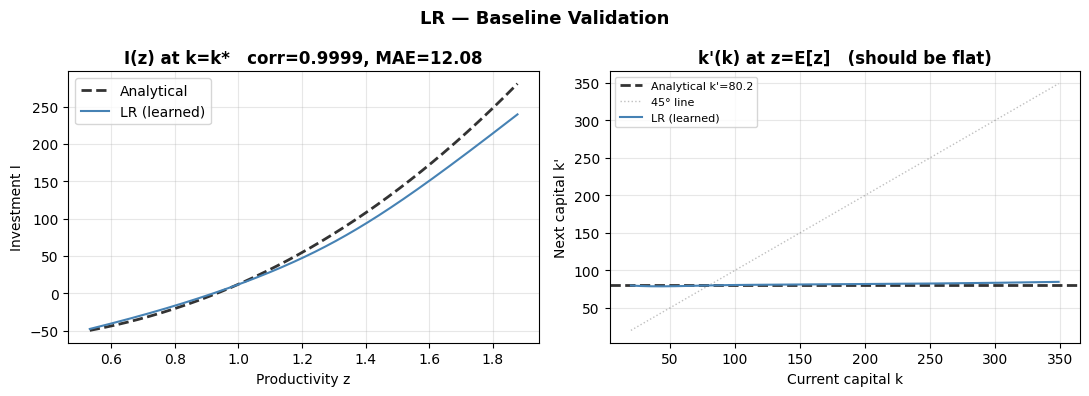

In [12]:
validate_policy(results["lr"]["policy"], "LR", "steelblue", save_name="lr")

In [ ]:
validate_policy(results["er"]["policy"], "ER", "darkorange", save_name="er")

In [ ]:
validate_policy(results["brm"]["policy"], "BRM", "seagreen", save_name="brm")

---
# Section 6: Checkpointing

Save trained models and history under `results/v2-{timestamp}/`.  
The `results/v2-latest` symlink always points to the most recent run.

In [ ]:
import json, dataclasses

if SAVE_RESULTS:
    for method_name, result in results.items():
        method_dir = os.path.join(CHECKPOINTS_DIR, "basic", "baseline", method_name)
        os.makedirs(method_dir, exist_ok=True)

        result["policy"].save(os.path.join(method_dir, "policy.keras"))

        if "value_net" in result:
            result["value_net"].save(os.path.join(method_dir, "value_net.keras"))

        with open(os.path.join(method_dir, "history.json"), "w") as f:
            json.dump(result["history"], f, indent=2)

        with open(os.path.join(method_dir, "config.json"), "w") as f:
            json.dump(dataclasses.asdict(result["config"]), f, indent=2)

        print(f"  Saved {method_name} -> {method_dir}/")

    with open(os.path.join(CHECKPOINTS_DIR, "params.json"), "w") as f:
        json.dump({"econ_params":  dataclasses.asdict(baseline_params),
                   "shock_params": dataclasses.asdict(shock_params)}, f, indent=2)

    print(f"\nAll checkpoints saved to: {CHECKPOINTS_DIR}")
    print(f"Stable path: results/v2-latest/checkpoints/")
else:
    print("SAVE_RESULTS=False: skipping")